# Analyse & visualisations

Données nettoyées exportées depuis `day-one.ipynb` (`data/cleaned/*.pkl`).

**Section 4 du sujet — EDA**

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option('display.min_rows', 6)
pd.set_option('display.max_columns', 12)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 20)
pd.set_option('display.width', 240)

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
})

FIGURES = Path('figures')
FIGURES.mkdir(exist_ok=True)
CLEANED = Path('data/cleaned')

orders = pd.read_pickle(CLEANED / 'orders.pkl')
territories = pd.read_pickle(CLEANED / 'territories.pkl')
sales = pd.read_pickle(CLEANED / 'sales.pkl')
resellers = pd.read_pickle(CLEANED / 'resellers.pkl')
dates = pd.read_pickle(CLEANED / 'dates.pkl')
products = pd.read_pickle(CLEANED / 'products.pkl')
customers = pd.read_pickle(CLEANED / 'customers.pkl')

# Vue enrichie pour l'EDA (ventes + territoire + produit)
sales_eda = (
    sales
    .merge(territories, on='SalesTerritoryKey', how='left')
    .merge(products[['ProductKey', 'Product', 'Model', 'Category', 'Subcategory']],
           on='ProductKey', how='left')
)

print(f'sales     : {len(sales):,}')
print(f'sales_eda : {len(sales_eda):,}  (doit être égal)')
print(f"OrderDate présent : {'OrderDate' in sales_eda.columns}")
assert len(sales_eda) == len(sales)
sales_eda.head()

sales     : 121,253
sales_eda : 121,253  (doit être égal)
OrderDate présent : True


,SalesOrderLineKey,ResellerKey,CustomerKey,ProductKey,OrderDateKey,DueDateKey,...,Country,Group,Product,Model,Category,Subcategory
0,43659001,676,-1,349,20170702,20170712,...,United States,North America,Mountain-100 Bla...,Mountain-100,Bikes,Mountain Bikes
1,43659002,676,-1,350,20170702,20170712,...,United States,North America,Mountain-100 Bla...,Mountain-100,Bikes,Mountain Bikes
2,43659003,676,-1,351,20170702,20170712,...,United States,North America,Mountain-100 Bla...,Mountain-100,Bikes,Mountain Bikes
3,43659004,676,-1,344,20170702,20170712,...,United States,North America,Mountain-100 Sil...,Mountain-100,Bikes,Mountain Bikes
4,43659005,676,-1,345,20170702,20170712,...,United States,North America,Mountain-100 Sil...,Mountain-100,Bikes,Mountain Bikes


## 4. Analyse Exploratoire des Données (EDA)

### 4.1 Total des ventes par territoire

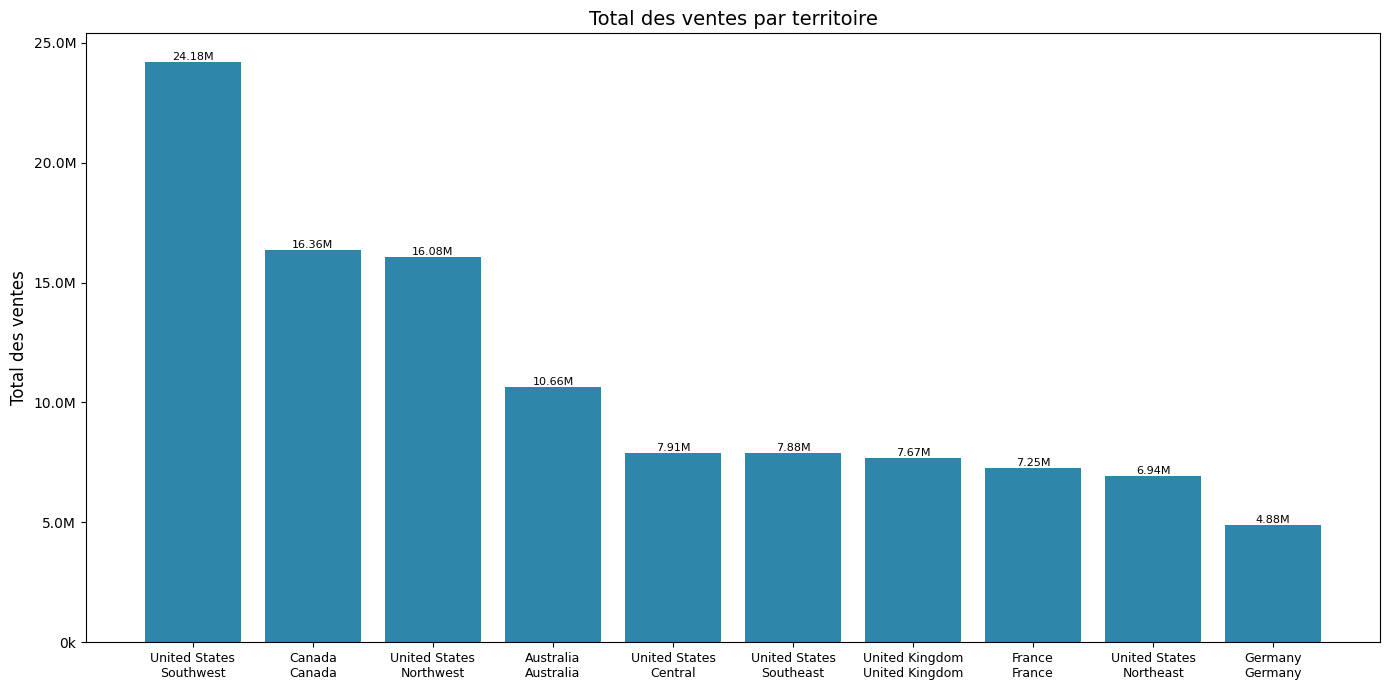

Sauvegardé : figures\sales_by_territory.png


,SalesTerritoryKey,Country,Region,Sales Amount
3,4,United States,Southwest,2.418461e+07
5,6,Canada,Canada,1.635577e+07
0,1,United States,Northwest,1.608494e+07
8,9,Australia,Australia,1.065534e+07
2,3,United States,Central,7.909009e+06
4,5,United States,Southeast,7.879655e+06
9,10,United Kingdom,United Kingdom,7.670721e+06
6,7,France,France,7.251556e+06
1,2,United States,Northeast,6.939374e+06
7,8,Germany,Germany,4.878300e+06


In [3]:
sales_by_territory = (
    sales_eda
    .groupby(['SalesTerritoryKey', 'Country', 'Region'], observed=True)['Sales Amount']
    .sum()
    .reset_index()
    .sort_values('Sales Amount', ascending=False)
)

# Labels : Country sur la 1re ligne, Region sur la 2e — intitulés horizontaux
labels = sales_by_territory['Country'].astype(str) + '\n' + sales_by_territory['Region'].astype(str)

fig, ax = plt.subplots(figsize=(14, 7))
bars = ax.bar(range(len(sales_by_territory)), sales_by_territory['Sales Amount'], color='#2E86AB')
ax.set_xticks(range(len(sales_by_territory)))
ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=9)
ax.set_ylabel('Total des ventes')
ax.set_title('Total des ventes par territoire')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k'))

for bar, val in zip(bars, sales_by_territory['Sales Amount']):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{val/1e6:.2f}M',
        ha='center', va='bottom', fontsize=8,
    )

fig.tight_layout()
out = FIGURES / 'sales_by_territory.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sauvegardé : {out}')
sales_by_territory

### 4.2 Total des ventes par Model de produit

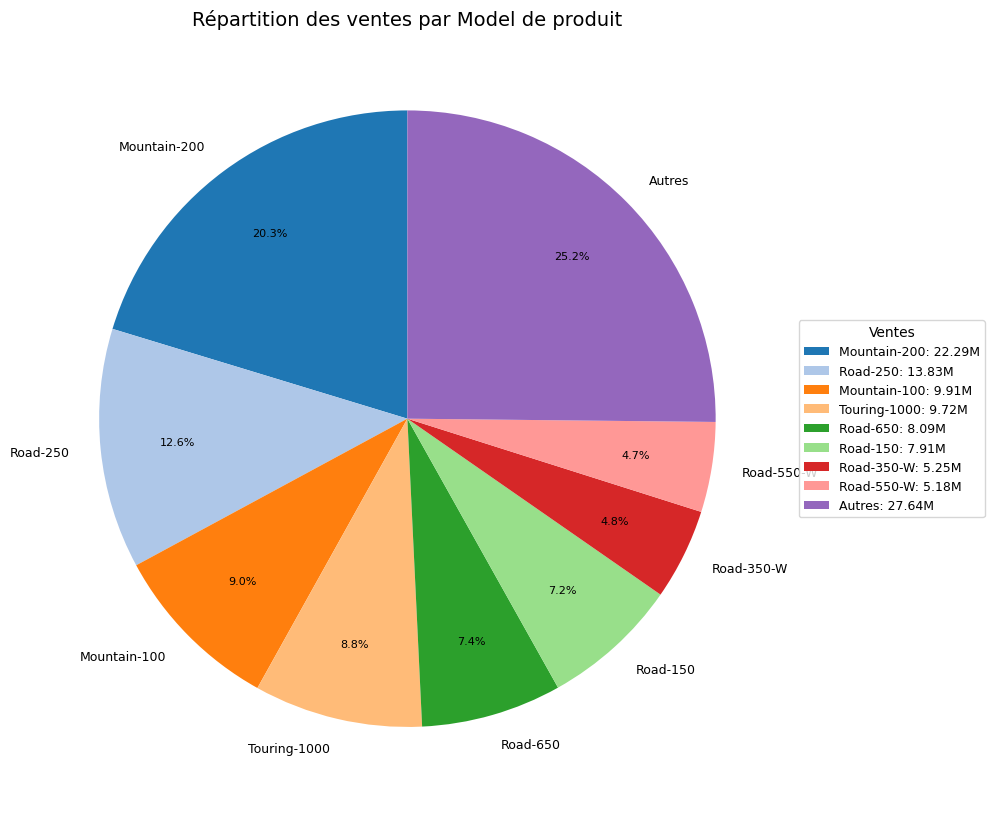

Sauvegardé : figures\sales_by_model.png


Model
Mountain-200         2.228617e+07
Road-250             1.382872e+07
Mountain-100         9.910079e+06
Touring-1000         9.715802e+06
Road-650             8.087521e+06
Road-150             7.913702e+06
Road-350-W           5.246152e+06
Road-550-W           5.183006e+06
HL Mountain Frame    3.365069e+06
Touring-3000         2.447377e+06
Touring-2000         2.133112e+06
Mountain-300         1.907249e+06
Road-450             1.874407e+06
Road-750             1.745285e+06
HL Touring Frame     1.347458e+06
Name: Sales Amount, dtype: float64

In [4]:
sales_by_model = (
    sales_eda
    .groupby('Model', observed=True)['Sales Amount']
    .sum()
    .sort_values(ascending=False)
)

# Top modèles + "Autres" pour garder un camembert lisible
TOP_N = 8
top = sales_by_model.head(TOP_N)
autres = sales_by_model.iloc[TOP_N:].sum()
pie_data = top.copy()
if autres > 0:
    pie_data.loc['Autres'] = autres

fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(
    pie_data.values,
    labels=pie_data.index.astype(str),
    autopct=lambda pct: f'{pct:.1f}%' if pct >= 2 else '',
    startangle=90,
    pctdistance=0.75,
    colors=plt.cm.tab20.colors[: len(pie_data)],
)
ax.set_title('Répartition des ventes par Model de produit')
for t in texts:
    t.set_fontsize(9)
for t in autotexts:
    t.set_fontsize(8)

# Légende avec montants en $
legend_labels = [
    f'{name}: {val/1e6:.2f}M' if val >= 1e6 else f'{name}: {val/1e3:.0f}k'
    for name, val in pie_data.items()
]
ax.legend(wedges, legend_labels, title='Ventes', loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9)

fig.tight_layout()
out = FIGURES / 'sales_by_model.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sauvegardé : {out}')
sales_by_model.head(15)

### Panier moyen & mix produit (slide 4)

Chiffres clés pour quantifier l'opportunité **cross-sell** (Accessories / Clothing sur les commandes vélos).


In [19]:
# --- Panier moyen : chiffres pour la slide 4 ---
sales_basket = sales_eda.merge(
    orders[['SalesOrderLineKey', 'Sales Order']],
    on='SalesOrderLineKey',
    how='left',
)

order_col = 'Sales Order'
total_ca = sales_basket['Sales Amount'].sum()

by_order = (
    sales_basket.groupby(order_col, observed=True)
    .agg(
        ca=('Sales Amount', 'sum'),
        nb_lignes=('SalesOrderLineKey', 'count'),
        categories=('Category', lambda s: frozenset(s.dropna())),
    )
)

panier_global = pd.Series(
    {
        'CA total (M$)': total_ca / 1e6,
        'Nb lignes': len(sales_basket),
        'Nb commandes': len(by_order),
        'Panier moyen par ligne ($)': sales_basket['Sales Amount'].mean(),
        'Médiane par ligne ($)': sales_basket['Sales Amount'].median(),
        'Panier moyen par commande ($)': by_order['ca'].mean(),
        'Médiane par commande ($)': by_order['ca'].median(),
        'Lignes moy. par commande': by_order['nb_lignes'].mean(),
    }
).round(2)

panier_categorie = (
    sales_basket.groupby('Category', observed=True)
    .agg(
        ca_total=('Sales Amount', 'sum'),
        moyenne_ligne=('Sales Amount', 'mean'),
        mediane_ligne=('Sales Amount', 'median'),
        nb_lignes=('SalesOrderLineKey', 'count'),
    )
    .assign(part_ca_pct=lambda d: (d['ca_total'] / total_ca * 100).round(1))
    .sort_values('ca_total', ascending=False)
)

bike_only = by_order[by_order['categories'].apply(lambda s: s == {'Bikes'})]
with_cross = by_order[by_order['categories'].apply(lambda s: bool(s & {'Accessories', 'Clothing'}))]

panier_mix = pd.DataFrame(
    {
        'Nb commandes': [len(bike_only), len(with_cross), len(by_order)],
        'Part des commandes (%)': [
            len(bike_only) / len(by_order) * 100,
            len(with_cross) / len(by_order) * 100,
            100.0,
        ],
        'Panier moyen ($)': [
            bike_only['ca'].mean(),
            with_cross['ca'].mean(),
            by_order['ca'].mean(),
        ],
    },
    index=['Vélo seul', 'Avec Access. / Clothing', 'Global'],
).round(2)

acc_cloth_ca = panier_categorie.loc[
    panier_categorie.index.isin(['Accessories', 'Clothing']), 'ca_total'
].sum()
potentiel_pct = 10 - (acc_cloth_ca / total_ca * 100)  # viser 10 % du mix
potentiel_ca = max(potentiel_pct, 0) / 100 * total_ca

print('=== Panier moyen — indicateurs globaux (slide 4) ===')
display(panier_global.to_frame('Valeur'))

print('\n=== Panier moyen par catégorie (par ligne) ===')
display(panier_categorie.round(2))

print('\n=== Mix commandes : vélo seul vs cross-sell ===')
display(panier_mix)

print('\n=== Opportunité cross-sell (chiffrée) ===')
print(
    f"Accessories + Clothing = {acc_cloth_ca/1e6:.1f} M$ "
    f"({acc_cloth_ca/total_ca*100:.1f} % du CA) — Bikes = "
    f"{panier_categorie.loc['Bikes', 'ca_total']/1e6:.1f} M$ "
    f"({panier_categorie.loc['Bikes', 'part_ca_pct']:.1f} %)"
)
print(
    f"Objectif : porter Access.+Clothing à ~10 % du mix → "
    f"potentiel +{potentiel_ca/1e6:.1f} M$ de CA"
)
print(
    f"Équivalent : +{potentiel_ca/len(by_order):,.0f} $ de panier moyen "
    f"si réparti sur toutes les commandes"
)


=== Panier moyen — indicateurs globaux (slide 4) ===


,Valeur
CA total (M$),109.81
Nb lignes,121253.00
Nb commandes,31455.00
Panier moyen par ligne ($),905.62
Médiane par ligne ($),134.98
Panier moyen par commande ($),3491.00
Médiane par commande ($),782.99
Lignes moy. par commande,3.85



=== Panier moyen par catégorie (par ligne) ===


,ca_total,moyenne_ligne,mediane_ligne,nb_lignes,part_ca_pct
Category,,,,,
Bikes,94620526.21,2365.22,1943.98,40005,86.2
Components,11799076.66,631.41,356.90,18687,10.7
Clothing,2117613.45,99.10,53.99,21368,1.9
Accessories,1272057.89,30.88,21.49,41193,1.2



=== Mix commandes : vélo seul vs cross-sell ===


,Nb commandes,Part des commandes (%),Panier moyen ($)
Vélo seul,7120,22.64,2326.61
Avec Access. / Clothing,23538,74.83,3599.89
Global,31455,100.00,3491.00



=== Opportunité cross-sell (chiffrée) ===
Accessories + Clothing = 3.4 M$ (3.1 % du CA) — Bikes = 94.6 M$ (86.2 %)
Objectif : porter Access.+Clothing à ~10 % du mix → potentiel +7.6 M$ de CA
Équivalent : +241 $ de panier moyen si réparti sur toutes les commandes


### 4.3 Ventes par jour & moyennes mobiles (7 et 30 jours)

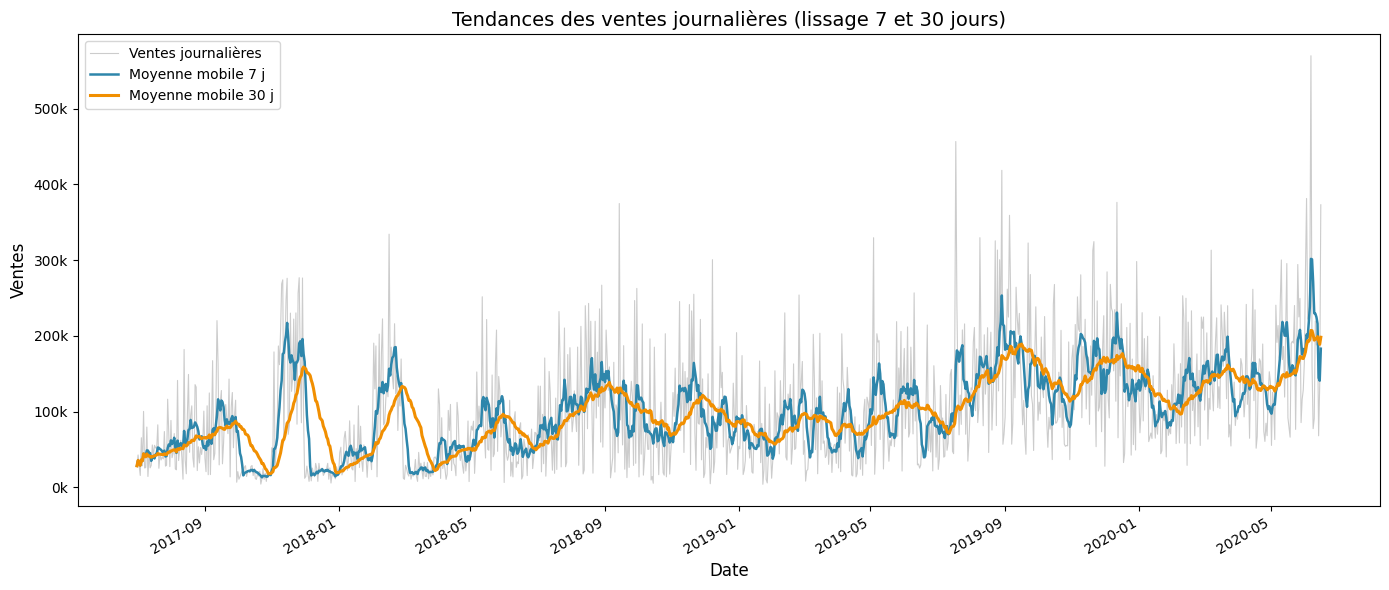

Sauvegardé : figures\sales_daily_rolling.png


,OrderDate,Sales Amount,MA_7,MA_30
1076,2020-06-11,187896.0920,224744.154171,196028.304663
1077,2020-06-12,206796.3412,216145.269971,198949.728670
1078,2020-06-13,68043.5916,144472.965743,194107.857517
1079,2020-06-14,135197.2501,140786.777486,188766.040470
1080,2020-06-15,373021.6019,183010.486743,198141.672573


In [5]:
daily_sales = (
    sales_eda
    .groupby('OrderDate', as_index=False)['Sales Amount']
    .sum()
    .sort_values('OrderDate')
)

daily_sales['MA_7'] = daily_sales['Sales Amount'].rolling(window=7, min_periods=1).mean()
daily_sales['MA_30'] = daily_sales['Sales Amount'].rolling(window=30, min_periods=1).mean()

fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(daily_sales['OrderDate'], daily_sales['Sales Amount'],
        color='#CCCCCC', linewidth=0.8, label='Ventes journalières')
ax.plot(daily_sales['OrderDate'], daily_sales['MA_7'],
        color='#2E86AB', linewidth=1.8, label='Moyenne mobile 7 j')
ax.plot(daily_sales['OrderDate'], daily_sales['MA_30'],
        color='#F18F01', linewidth=2.2, label='Moyenne mobile 30 j')

ax.set_title('Tendances des ventes journalières (lissage 7 et 30 jours)')
ax.set_xlabel('Date')
ax.set_ylabel('Ventes')
ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
fig.autofmt_xdate()
fig.tight_layout()

out = FIGURES / 'sales_daily_rolling.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sauvegardé : {out}')
daily_sales.tail()

### 4.4 Tableaux croisés dynamiques (pivot tables)

In [6]:
# Somme des ventes par produit et territoire (Country / Region)
pivot_product_territory = pd.pivot_table(
    sales_eda,
    values='Sales Amount',
    index='Product',
    columns=['Country', 'Region'],
    aggfunc='sum',
    fill_value=0,
    observed=True,
)

# Ventes par Category × Group territorial
pivot_category_group = pd.pivot_table(
    sales_eda,
    values='Sales Amount',
    index='Category',
    columns='Group',
    aggfunc='sum',
    fill_value=0,
    observed=True,
)

# Quantité + ventes par Model × Country
pivot_model_country = pd.pivot_table(
    sales_eda,
    values=['Sales Amount', 'Order Quantity'],
    index='Model',
    columns='Country',
    aggfunc='sum',
    fill_value=0,
    observed=True,
)

print('=== Ventes Product × Territoire (aperçu) ===')
display(pivot_product_territory.head(10).round(0))

print('\n=== Ventes Category × Group ===')
display(pivot_category_group.round(0))

print('\n=== Model × Country (Sales Amount) ===')
display(pivot_model_country['Sales Amount'].head(12).round(0))

=== Ventes Product × Territoire (aperçu) ===


Country              Australia   Canada   France  Germany United Kingdom United States                                        
Region               Australia   Canada   France  Germany United Kingdom       Central Northeast Northwest Southeast Southwest
Product                                                                                                                       
AWC Logo Cap            4829.0   9327.0   3933.0   3920.0         4829.0        3015.0    2680.0    5652.0    2775.0   10269.0
All-Purpose Bike ...   10335.0   5088.0   3021.0   3180.0         4452.0           0.0       0.0    5724.0       0.0    7791.0
Bike Wash - Disso...    2286.0   3269.0   1460.0   1379.0         1588.0         816.0    1111.0    2407.0     859.0    3232.0
Cable Lock                 0.0   4210.0   1050.0      0.0          735.0        1620.0    1455.0    1560.0    1296.0    4299.0
Chain                    850.0   1142.0   1232.0    522.0          660.0         534.0     644.0    1664.0     267.0    1863.0
Classic Vest, L         2794.0   2045.0   1206.0    635.0         1003.0          38.0     102.0    2032.0      64.0    2921.0
Classic Vest, M         6804.0  17620.0   8433.0   7946.0         8894.0        5579.0    7140.0    8768.0    5670.0   13396.0
Classic Vest, S        11468.0  28437.0  13973.0  14470.0        12139.0       10446.0   13912.0   13436.0   11333.0   26784.0
Fender Set - Moun...    7144.0   8792.0   2242.0   3539.0         3165.0          22.0      22.0    9188.0      66.0   12441.0
Front Brakes            3770.0   8014.0   5707.0   1789.0         4920.0        2876.0    3605.0    8882.0    1789.0    8946.0


=== Ventes Category × Group ===


Group,Europe,North America,Pacific
Category,,,
Accessories,327977.0,781442.0,162638.0
Bikes,17154361.0,67290294.0,10175871.0
Clothing,401381.0,1603057.0,113176.0
Components,1916858.0,9678567.0,203651.0



=== Model × Country (Sales Amount) ===


Country,Australia,Canada,France,Germany,United Kingdom,United States
Model,,,,,,
All-Purpose Bike Stand,10335.0,5088.0,3021.0,3180.0,4452.0,13515.0
Bike Wash,2286.0,3269.0,1460.0,1379.0,1588.0,8426.0
Cable Lock,0.0,4210.0,1050.0,0.0,735.0,10230.0
Chain,850.0,1142.0,1232.0,522.0,660.0,4972.0
Classic Vest,21066.0,48102.0,23613.0,23050.0,22036.0,121621.0
Cycling Cap,4829.0,9327.0,3933.0,3920.0,4829.0,24392.0
Fender Set - Mountain,7144.0,8792.0,2242.0,3539.0,3165.0,21738.0
Front Brakes,3770.0,8014.0,5707.0,1789.0,4920.0,26098.0
Front Derailleur,5215.0,7338.0,5472.0,2470.0,3568.0,20421.0


## Jour 2 — Analyse avancée & visualisation

Suite du sujet : statistiques, viz avancées, temporel, fusions, revendeurs, présentation.


## 5. Analyse statistique des données

### 5.1 Stats classiques des ventes par territoire


In [7]:
stats_by_territory = (
    sales_eda
    .groupby(['Country', 'Region'], observed=True)['Sales Amount']
    .agg(
        moyenne='mean',
        mediane='median',
        ecart_type='std',
        minimum='min',
        maximum='max',
        q1=lambda s: s.quantile(0.25),
        q3=lambda s: s.quantile(0.75),
    )
    .round(2)
    .sort_values('moyenne', ascending=False)
)
stats_by_territory


moyenne  mediane  ecart_type  minimum   maximum      q1       q3
Country        Region                                                                          
United States  Central         1356.14   469.79     2221.75     1.37  27055.76  125.42  1619.97
               Southeast       1318.55   445.41     2175.63     1.37  24938.48  115.36  1471.70
               Northeast       1189.06   449.94     1753.82     1.37  14880.00  136.76  1430.44
               Northwest        953.75    86.52     1916.08     1.37  21101.79   24.29  1120.49
               Southwest        943.09   149.03     1746.77     1.37  27893.62   28.84  1200.31
Canada         Canada           857.94   127.80     1688.14     1.37  23020.13   26.72   890.82
France         France           797.93    64.79     1583.30     2.29  23667.85   21.49   923.39
United Kingdom United Kingdom   735.73    53.99     1402.64     1.37  22422.18    9.99   890.82
Australia      Australia        707.62    35.00     1119.90     2.29  17616.37    8.99  1120.49
Germany        Germany          653.58    35.00     1263.61     1.37  19930.83    8.99   769.49

### 5.2 Corrélations


In [8]:
corr_sales_margin = sales_eda[['Sales Amount', 'Margin']].corr().iloc[0, 1]
corr_cost_margin = sales_eda[['Total Product Cost', 'Margin']].corr().iloc[0, 1]

print(f"Corrélation ventes totales ↔ marge (profits) : {corr_sales_margin:.4f}")
print(f"Corrélation coût total ↔ marge              : {corr_cost_margin:.4f}")

sales_eda[['Sales Amount', 'Margin', 'Total Product Cost', 'Unit Price']].corr().round(3)


Corrélation ventes totales ↔ marge (profits) : 0.2005
Corrélation coût total ↔ marge              : -0.0358


,Sales Amount,Margin,Total Product Cost,Unit Price
Sales Amount,1.000,0.201,0.972,0.646
Margin,0.201,1.000,-0.036,0.600
Total Product Cost,0.972,-0.036,1.000,0.515
Unit Price,0.646,0.600,0.515,1.000


### 5.3 Territoires & produits les plus performants + écart-type par territoire


In [9]:
top_territories = (
    sales_eda.groupby(['Country', 'Region'], observed=True)['Sales Amount']
    .sum()
    .sort_values(ascending=False)
    .head(5)
)
top_products = (
    sales_eda.groupby('Product', observed=True)['Sales Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

std_by_territory = (
    sales_eda.groupby(['Country', 'Region'], observed=True)['Sales Amount']
    .std()
    .sort_values(ascending=False)
)

print('=== Top 5 territoires (somme des ventes) ===')
display(top_territories.round(2))
print('\n=== Top 10 produits ===')
display(top_products.round(2))
print('\n=== Écart-type des ventes par territoire ===')
display(std_by_territory.round(2))

cv = (
    sales_eda.groupby(['Country', 'Region'], observed=True)['Sales Amount']
    .agg(moyenne='mean', ecart_type='std')
)
cv['cv'] = (cv['ecart_type'] / cv['moyenne']).round(3)
print('\n=== Coefficient de variation (σ / μ) par territoire ===')
display(cv.sort_values('cv', ascending=False))


=== Top 5 territoires (somme des ventes) ===


Country        Region   
United States  Southwest    24184609.60
Canada         Canada       16355770.46
United States  Northwest    16084942.55
Australia      Australia    10655335.96
United States  Central       7909009.01
Name: Sales Amount, dtype: float64


=== Top 10 produits ===


Product
Mountain-200 Black, 38     4400592.80
Mountain-200 Black, 42     4009494.76
Mountain-200 Silver, 38    3693678.03
Mountain-200 Silver, 42    3438478.86
Mountain-200 Silver, 46    3434256.94
Mountain-200 Black, 46     3309673.22
Road-250 Black, 44         2516857.31
Road-250 Black, 48         2347655.95
Road-250 Black, 52         2012447.78
Road-150 Red, 56           1847818.63
Name: Sales Amount, dtype: float64


=== Écart-type des ventes par territoire ===


Country         Region        
United States   Central           2221.75
                Southeast         2175.63
                Northwest         1916.08
                Northeast         1753.82
                Southwest         1746.77
Canada          Canada            1688.14
France          France            1583.30
United Kingdom  United Kingdom    1402.64
Germany         Germany           1263.61
Australia       Australia         1119.90
Name: Sales Amount, dtype: float64


=== Coefficient de variation (σ / μ) par territoire ===


moyenne   ecart_type     cv
Country        Region                                         
United States  Northwest        953.746964  1916.078655  2.009
France         France           797.926458  1583.301934  1.984
Canada         Canada           857.940121  1688.137047  1.968
Germany        Germany          653.577221  1263.609925  1.933
United Kingdom United Kingdom   735.730006  1402.643964  1.906
United States  Southwest        943.090376  1746.767678  1.852
               Southeast       1318.550046  2175.632153  1.650
               Central         1356.140090  2221.745029  1.638
Australia      Australia        707.619602  1119.895723  1.583
United States  Northeast       1189.063482  1753.823152  1.475

## 6. Visualisation avancée (Matplotlib)

Thème / police personnalisés pour les graphiques suivants.


In [10]:
plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'axes.titleweight': 'bold',
    'axes.prop_cycle': plt.cycler(
        color=['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B', '#44AF69']
    ),
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FFFFFF',
    'axes.grid': True,
    'grid.alpha': 0.25,
})
print('Thème matplotlib appliqué.')


Thème matplotlib appliqué.


### 6.1 Nuage de points — ventes × marge (intensité = prix unitaire)


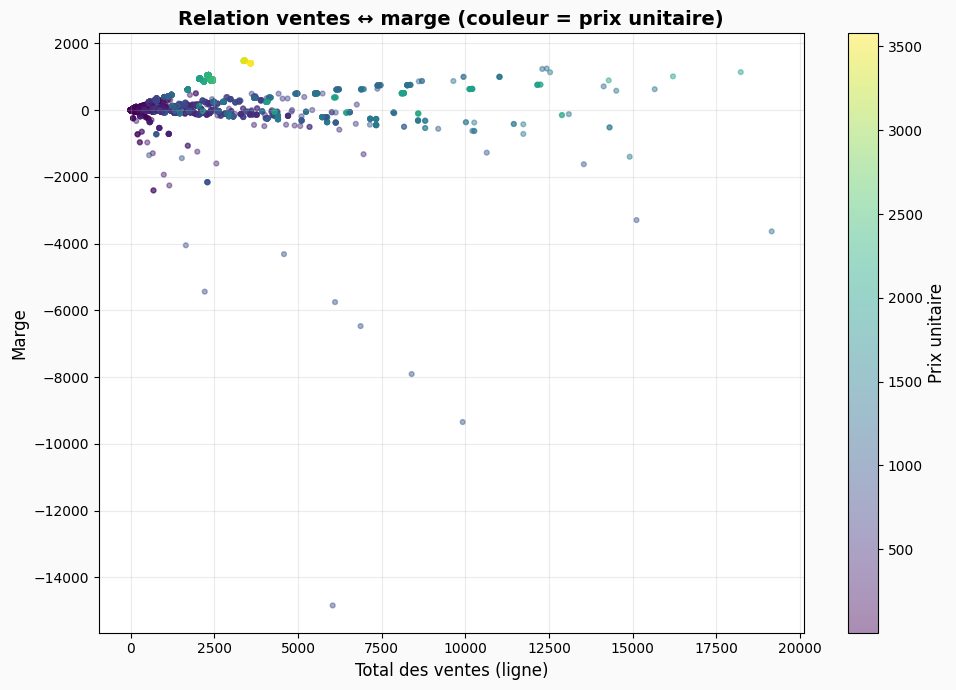

Sauvegardé : figures\scatter_sales_margin.png


In [11]:
scatter_df = sales_eda.sample(n=min(8000, len(sales_eda)), random_state=42)

fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    scatter_df['Sales Amount'],
    scatter_df['Margin'],
    c=scatter_df['Unit Price'],
    cmap='viridis',
    alpha=0.45,
    s=12,
)
cb = fig.colorbar(sc, ax=ax)
cb.set_label('Prix unitaire')
ax.set_xlabel('Total des ventes (ligne)')
ax.set_ylabel('Marge')
ax.set_title('Relation ventes ↔ marge (couleur = prix unitaire)')
fig.tight_layout()
out = FIGURES / 'scatter_sales_margin.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sauvegardé : {out}')


### 6.2 Box plot — distribution des ventes par territoire (valeurs par Model)


C:\Users\brann\AppData\Local\Temp\ipykernel_29592\3190929989.py:22: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_boxes, labels=order, showfliers=False, patch_artist=True)


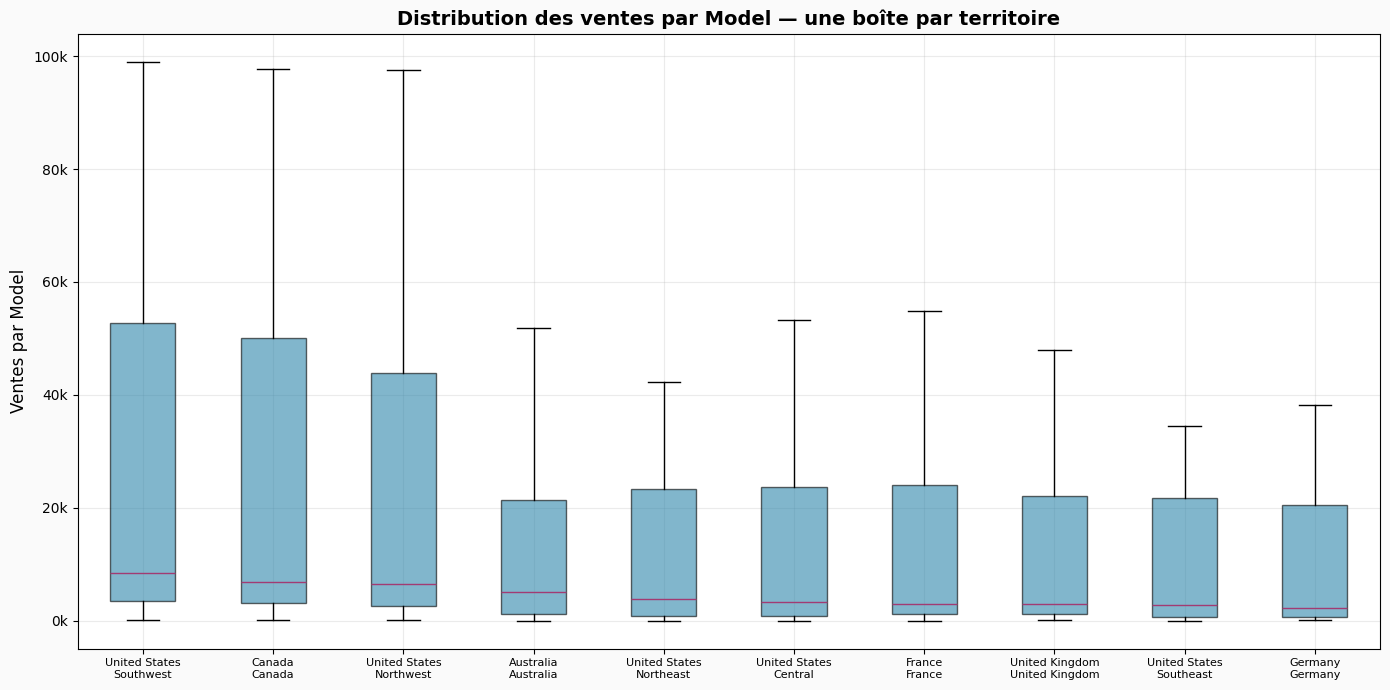

Sauvegardé : figures\boxplot_territory_model.png


In [12]:
model_terr = (
    sales_eda
    .groupby(['Country', 'Region', 'Model'], observed=True)['Sales Amount']
    .sum()
    .reset_index()
)
model_terr['Territoire'] = (
    model_terr['Country'].astype(str) + '\n' + model_terr['Region'].astype(str)
)

order = (
    model_terr.groupby('Territoire')['Sales Amount']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)
data_boxes = [
    model_terr.loc[model_terr['Territoire'] == t, 'Sales Amount'].values for t in order
]

fig, ax = plt.subplots(figsize=(14, 7))
bp = ax.boxplot(data_boxes, labels=order, showfliers=False, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#2E86AB')
    patch.set_alpha(0.6)
ax.set_ylabel('Ventes par Model')
ax.set_title('Distribution des ventes par Model — une boîte par territoire')
ax.yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k')
)
plt.setp(ax.get_xticklabels(), rotation=0, ha='center', fontsize=8)
fig.tight_layout()
out = FIGURES / 'boxplot_territory_model.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sauvegardé : {out}')


### 6.3 Heatmap de corrélation + camembert parts de marché


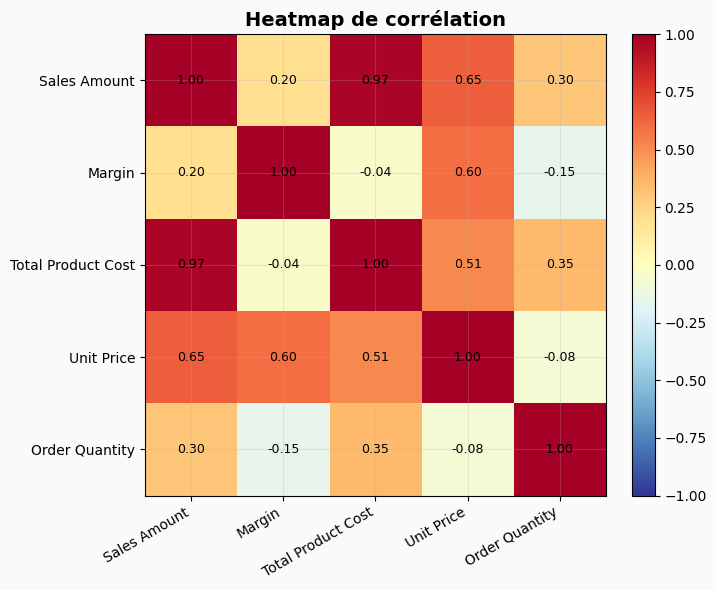

Sauvegardé : figures\heatmap_corr.png


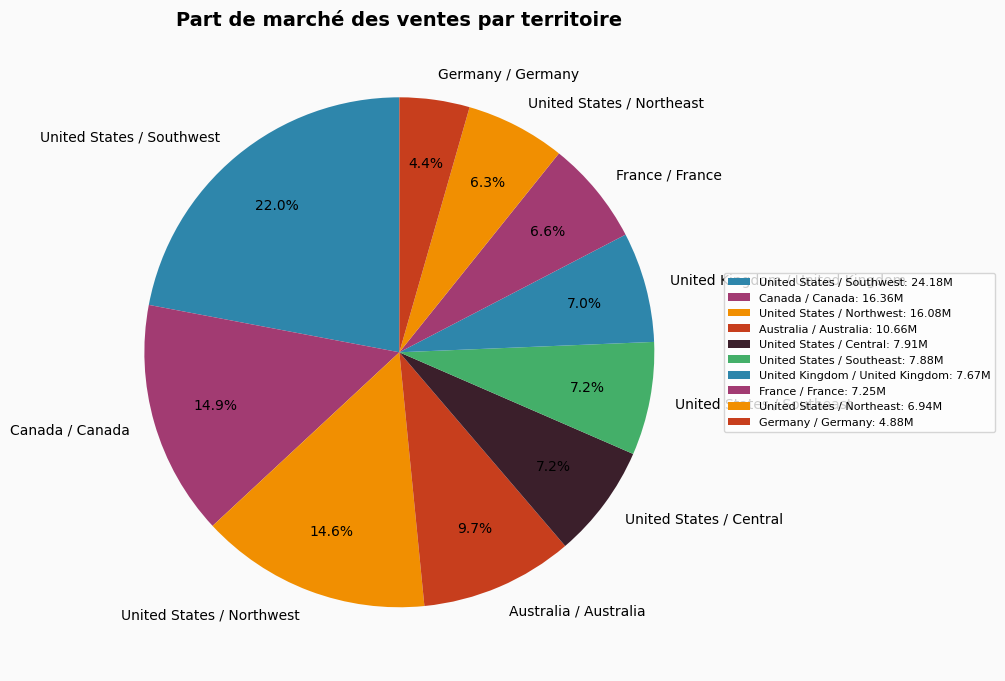

Sauvegardé : figures\pie_territory_share.png


In [13]:
corr_cols = ['Sales Amount', 'Margin', 'Total Product Cost', 'Unit Price', 'Order Quantity']
corr_matrix = sales_eda[corr_cols].corr()

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr_matrix, cmap='RdYlBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=30, ha='right')
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f'{corr_matrix.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)
fig.colorbar(im, ax=ax, fraction=0.046)
ax.set_title('Heatmap de corrélation')
fig.tight_layout()
out = FIGURES / 'heatmap_corr.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sauvegardé : {out}')

terr_share = (
    sales_eda.groupby(['Country', 'Region'], observed=True)['Sales Amount']
    .sum()
    .sort_values(ascending=False)
)
labels_pie = [f'{c} / {r}' for c, r in terr_share.index]
fig, ax = plt.subplots(figsize=(10, 10))
wedges, texts, autotexts = ax.pie(
    terr_share.values,
    labels=labels_pie,
    autopct=lambda pct: f'{pct:.1f}%' if pct >= 3 else '',
    startangle=90,
    pctdistance=0.75,
)
ax.set_title('Part de marché des ventes par territoire')
legend_labels = [f'{lab}: {val/1e6:.2f}M' for lab, val in zip(labels_pie, terr_share.values)]
ax.legend(wedges, legend_labels, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=8)
fig.tight_layout()
out = FIGURES / 'pie_territory_share.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sauvegardé : {out}')


## 7. Analyse temporelle des ventes


=== Ventes annuelles ===


OrderDate
2017-12-31    11928555.52
2018-12-31    30516891.80
2019-12-31    42895109.50
2020-12-31    24468717.39
Freq: YE-DEC, Name: Sales Amount, dtype: float64


=== Ventes trimestrielles (aperçu) ===


OrderDate
2018-09-30    10192098.13
2018-12-31     8392458.01
2019-03-31     6769487.90
2019-06-30     8716064.45
2019-09-30    13864317.31
2019-12-31    13545239.84
2020-03-31    11735065.66
2020-06-30    12733651.73
Freq: QE-DEC, Name: Sales Amount, dtype: float64


=== Ventes mensuelles (aperçu) ===


Month
2019-07-01    3513064.05
2019-08-01    5247165.33
2019-09-01    5104087.93
2019-10-01    3542149.58
2019-11-01    5151896.58
2019-12-01    4851193.68
2020-01-01    3235187.23
2020-02-01    4070045.89
2020-03-01    4429832.53
2020-04-01    4002614.35
2020-05-01    5265796.68
2020-06-01    3465240.69
Freq: MS, Name: Sales Amount, dtype: float64

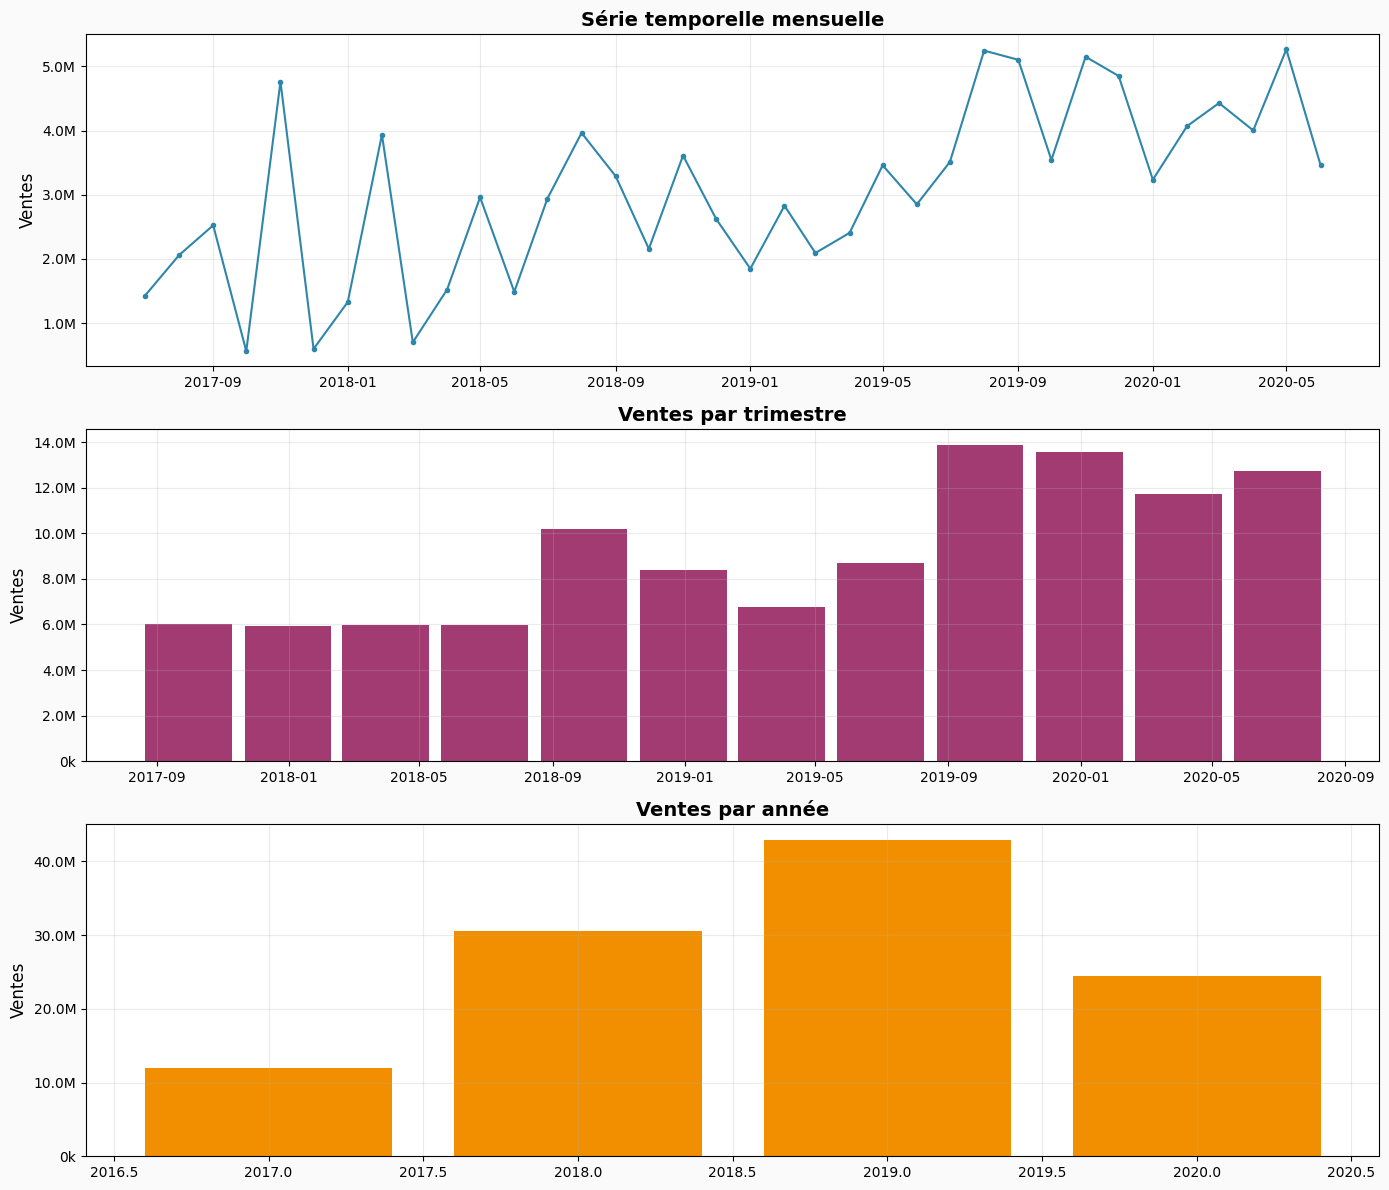

Sauvegardé : figures\sales_temporal.png


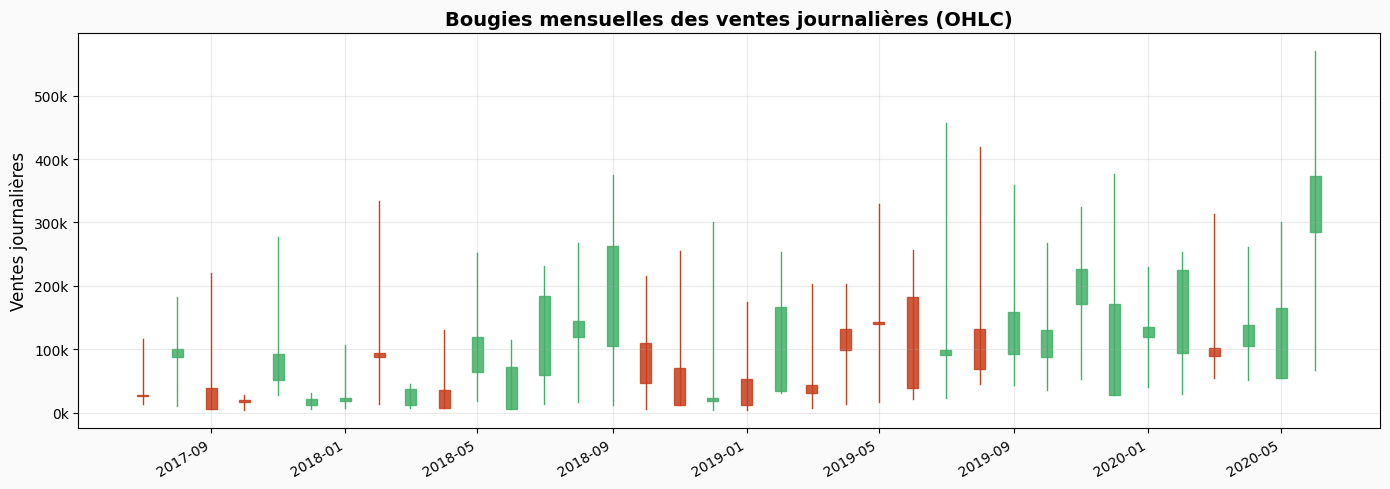

Sauvegardé : figures\sales_candles_monthly.png


In [14]:
monthly = (
    sales_eda.set_index('OrderDate')['Sales Amount']
    .resample('MS')
    .sum()
    .rename('Sales Amount')
)
monthly.index.name = 'Month'

quarterly = sales_eda.set_index('OrderDate')['Sales Amount'].resample('QE').sum()
yearly = sales_eda.set_index('OrderDate')['Sales Amount'].resample('YE').sum()

print('=== Ventes annuelles ===')
display(yearly.round(2))
print('\n=== Ventes trimestrielles (aperçu) ===')
display(quarterly.tail(8).round(2))
print('\n=== Ventes mensuelles (aperçu) ===')
display(monthly.tail(12).round(2))

fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=False)
axes[0].plot(monthly.index, monthly.values, color='#2E86AB', marker='o', markersize=3)
axes[0].set_title('Série temporelle mensuelle')
axes[0].set_ylabel('Ventes')
axes[1].bar(quarterly.index, quarterly.values, width=80, color='#A23B72', align='center')
axes[1].set_title('Ventes par trimestre')
axes[1].set_ylabel('Ventes')
axes[2].bar(yearly.index.year, yearly.values, color='#F18F01')
axes[2].set_title('Ventes par année')
axes[2].set_ylabel('Ventes')
for ax in axes:
    ax.yaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M' if x >= 1e6 else f'{x/1e3:.0f}k')
    )
fig.tight_layout()
out = FIGURES / 'sales_temporal.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sauvegardé : {out}')

daily = sales_eda.groupby('OrderDate')['Sales Amount'].sum().sort_index()
ohlc = daily.resample('MS').agg(Open='first', High='max', Low='min', Close='last')

fig, ax = plt.subplots(figsize=(14, 5))
width = 10
for dt, row in ohlc.iterrows():
    color = '#44AF69' if row['Close'] >= row['Open'] else '#C73E1D'
    ax.plot([dt, dt], [row['Low'], row['High']], color=color, linewidth=1)
    lo = min(row['Open'], row['Close'])
    hi = abs(row['Close'] - row['Open'])
    ax.add_patch(
        plt.Rectangle(
            (dt - pd.Timedelta(days=width / 2), lo),
            pd.Timedelta(days=width),
            hi if hi > 0 else 1,
            facecolor=color,
            edgecolor=color,
            alpha=0.85,
        )
    )
ax.set_title('Bougies mensuelles des ventes journalières (OHLC)')
ax.set_ylabel('Ventes journalières')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
fig.autofmt_xdate()
fig.tight_layout()
out = FIGURES / 'sales_candles_monthly.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sauvegardé : {out}')


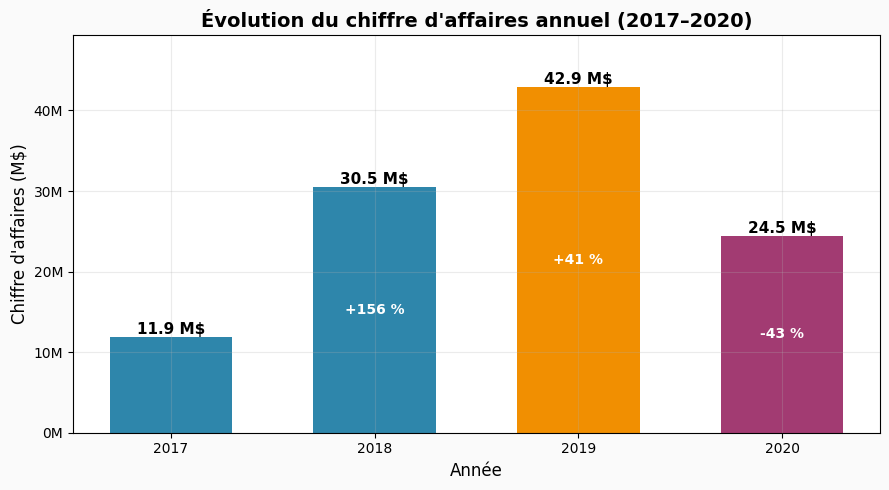

Sauvegardé : figures\sales_yearly.png


In [15]:
# Slide 5 — graphique annuel lisible (1 message, chiffres visibles)
years = yearly.index.year.astype(int)
values = yearly.values

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#2E86AB', '#2E86AB', '#F18F01', '#A23B72']
bars = ax.bar(years.astype(str), values, color=colors, width=0.6)
ax.set_title('Évolution du chiffre d\'affaires annuel (2017–2020)')
ax.set_xlabel('Année')
ax.set_ylabel('Chiffre d\'affaires (M$)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.0f}M'))

for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{val/1e6:.1f} M$',
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold',
    )

pct_changes = [None]
for i in range(1, len(values)):
    pct = (values[i] - values[i - 1]) / values[i - 1] * 100
    pct_changes.append(pct)

for i, pct in enumerate(pct_changes):
    if pct is not None:
        sign = '+' if pct >= 0 else ''
        ax.text(
            i,
            values[i] * 0.5,
            f'{sign}{pct:.0f} %',
            ha='center',
            va='center',
            fontsize=10,
            color='white',
            fontweight='bold',
        )

ax.set_ylim(0, max(values) * 1.15)
fig.tight_layout()
out = FIGURES / 'sales_yearly.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sauvegardé : {out}')


## 8. Fusion des données pour une analyse globale


In [16]:
sales_full = (
    sales
    .merge(orders, on='SalesOrderLineKey', how='left')
    .merge(territories, on='SalesTerritoryKey', how='left')
    .merge(products, on='ProductKey', how='left')
    .merge(resellers, on='ResellerKey', how='left', suffixes=('', '_reseller'))
    .merge(customers, on='CustomerKey', how='left', suffixes=('', '_cust'))
    .merge(
        dates[['DateKey', 'Date']],
        left_on='OrderDateKey',
        right_on='DateKey',
        how='left',
    )
)

print(f'Lignes sales      : {len(sales):,}')
print(f'Lignes sales_full : {len(sales_full):,}')
assert len(sales_full) == len(sales), 'Des lignes sales ont été perdues au merge !'
print('OK — toutes les lignes sales sont présentes.')
print(f'Colonnes : {sales_full.shape[1]}')
sales_full.head(3)


Lignes sales      : 121,253
Lignes sales_full : 121,253
OK — toutes les lignes sales sont présentes.
Colonnes : 50


,SalesOrderLineKey,ResellerKey,CustomerKey,ProductKey,OrderDateKey,DueDateKey,...,City_cust,State-Province_cust,Country-Region_cust,Postal Code_cust,DateKey,Date
0,43659001,676,-1,349,20170702,20170712,...,[Not Applicable],[Not Applicable],[Not Applicable],[Not Applicable],20170702,2017-07-02
1,43659002,676,-1,350,20170702,20170712,...,[Not Applicable],[Not Applicable],[Not Applicable],[Not Applicable],20170702,2017-07-02
2,43659003,676,-1,351,20170702,20170712,...,[Not Applicable],[Not Applicable],[Not Applicable],[Not Applicable],20170702,2017-07-02


### 8.1 Analyses croisées


=== Top ventes produit × territoire ===


Product                  Country        Region   
Mountain-200 Black, 38   United States  Southwest    869681.54
Mountain-200 Black, 42   United States  Southwest    835830.23
Mountain-200 Silver, 38  United States  Southwest    782814.34
Mountain-200 Black, 38   United States  Northwest    779305.85
Mountain-200 Black, 46   United States  Southwest    756771.08
Mountain-200 Black, 38   Canada         Canada       735839.95
Mountain-200 Silver, 42  United States  Southwest    695367.29
Mountain-200 Silver, 46  United States  Southwest    680827.58
Mountain-200 Black, 42   United States  Northwest    678674.83
Mountain-200 Black, 46   United States  Northwest    656404.38
Mountain-200 Black, 42   Canada         Canada       642039.84
Mountain-200 Silver, 42  United States  Northwest    623169.57
Mountain-200 Silver, 46  United States  Northwest    615094.58
Mountain-200 Silver, 38  United States  Northwest    591580.45
Road-250 Black, 44       United States  Southwest    560723.52
Name:


=== Nombre de produits par Model ===


Model
LL Road Frame              30
HL Road Frame              25
Road-650                   24
HL Mountain Frame          22
Road-250                   13
Mountain-200               12
Long-Sleeve Logo Jersey    12
Road-550-W                 10
Touring-3000               10
ML Road Frame-W            10
Mountain-500               10
LL Mountain Frame          10
LL Touring Frame           10
Sport-100                   9
Touring-1000                8
Name: ProductKey, dtype: int64


=== Clients — plus de commandes ===


,,nb_lignes,nb_commandes
CustomerKey,Customer,,
11091,Dalton Perez,59,28
11176,Mason Roberts,60,28
11200,Jason Griffin,55,27
11185,Ashley Henderson,68,27
11711,Daniel Davis,55,27
11277,Charles Jackson,65,27
11331,Samantha Jenkins,58,27
11330,Ryan Thompson,57,27
11223,Hailey Patterson,56,27



=== Clients — plus gros dépenses ===


CustomerKey  Customer         
12301        Nichole Nara         13295.38
12132        Kaitlyn Henderson    13294.27
12308        Margaret He          13269.27
12131        Randall Dominguez    13265.99
12300        Adriana Gonzalez     13242.70
12321        Rosa Hu              13215.65
12124        Brandi Gill          13195.64
12307        Brad She             13173.19
12296        Francisco Sara       13164.64
11433        Maurice Shan         12909.67
Name: Sales Amount, dtype: float64


=== Nb ventes par Category × territoire (top 15) ===


Category     Country         Region        
Bikes        United States   Southwest         8605
Accessories  United States   Southwest         8386
             Australia       Australia         7178
             Canada          Canada            6392
             United States   Northwest         6176
Bikes        Canada          Canada            5366
             Australia       Australia         5241
             United States   Northwest         5187
Clothing     United States   Southwest         4455
Accessories  United Kingdom  United Kingdom    4392
Components   United States   Southwest         4198
Clothing     Canada          Canada            3872
Accessories  France          France            3668
             Germany         Germany           3518
Components   Canada          Canada            3434
Name: nb_ventes, dtype: int64

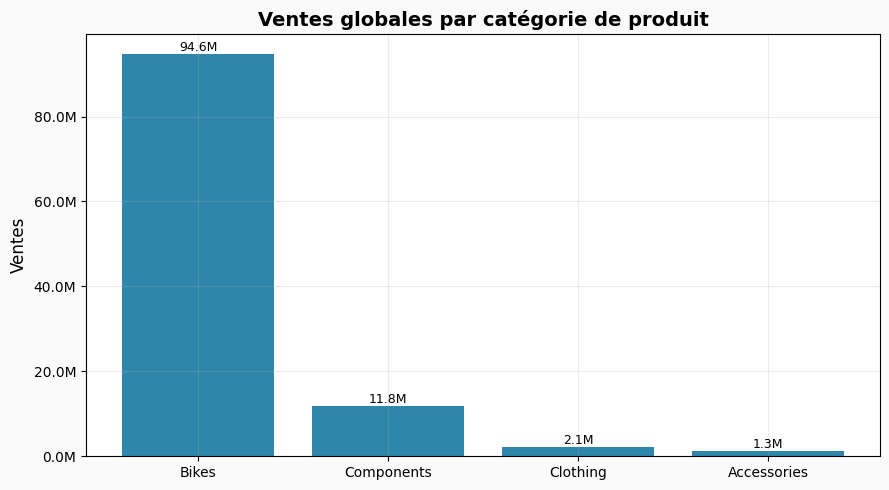

Sauvegardé : figures\sales_by_category.png


In [17]:
cross_prod_terr = (
    sales_full.groupby(['Product', 'Country', 'Region'], observed=True)['Sales Amount']
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

products_per_model = (
    products.groupby('Model', observed=True)['ProductKey']
    .nunique()
    .sort_values(ascending=False)
)

order_col = 'Sales Order' if 'Sales Order' in sales_full.columns else 'SalesOrderLineKey'
top_customers_orders = (
    sales_full.loc[sales_full['CustomerKey'] != -1]
    .groupby(['CustomerKey', 'Customer'], observed=True)
    .agg(nb_lignes=('SalesOrderLineKey', 'count'), nb_commandes=(order_col, 'nunique'))
    .sort_values('nb_commandes', ascending=False)
    .head(10)
)

top_customers_spend = (
    sales_full.loc[sales_full['CustomerKey'] != -1]
    .groupby(['CustomerKey', 'Customer'], observed=True)['Sales Amount']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

cat_terr_count = (
    sales_full.groupby(['Category', 'Country', 'Region'], observed=True)
    .size()
    .rename('nb_ventes')
    .sort_values(ascending=False)
)

print('=== Top ventes produit × territoire ===')
display(cross_prod_terr.round(2))
print('\n=== Nombre de produits par Model ===')
display(products_per_model.head(15))
print('\n=== Clients — plus de commandes ===')
display(top_customers_orders)
print('\n=== Clients — plus gros dépenses ===')
display(top_customers_spend.round(2))
print('\n=== Nb ventes par Category × territoire (top 15) ===')
display(cat_terr_count.head(15))

cat_sales = (
    sales_full.groupby('Category', observed=True)['Sales Amount']
    .sum()
    .sort_values(ascending=False)
)
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(cat_sales.index.astype(str), cat_sales.values, color='#2E86AB')
ax.set_title('Ventes globales par catégorie de produit')
ax.set_ylabel('Ventes')
for bar, val in zip(bars, cat_sales.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f'{val/1e6:.1f}M',
        ha='center',
        va='bottom',
        fontsize=9,
    )
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
fig.tight_layout()
out = FIGURES / 'sales_by_category.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sauvegardé : {out}')


## 9. Performances des revendeurs


=== Top 10 revendeurs ===


,,ventes,marge,nb_lignes
ResellerKey,Reseller,,,
697,Brakes and Gears,877107.19,62737.64,298
170,Excellent Riding Supplies,853849.18,-19428.98,366
678,Vigorous Exercise Company,841908.77,2130.25,530
328,Totes & Baskets Company,816755.58,-18639.52,436
514,Retail Mall,799277.90,-22993.42,451
155,Corner Bicycle Supply,787773.04,-13782.51,429
72,Outdoor Equipment Store,746317.53,-27918.47,332
433,Thorough Parts and Repair Services,740985.83,-24512.87,358
227,"Health Spa, Limited",730798.71,-26332.82,352


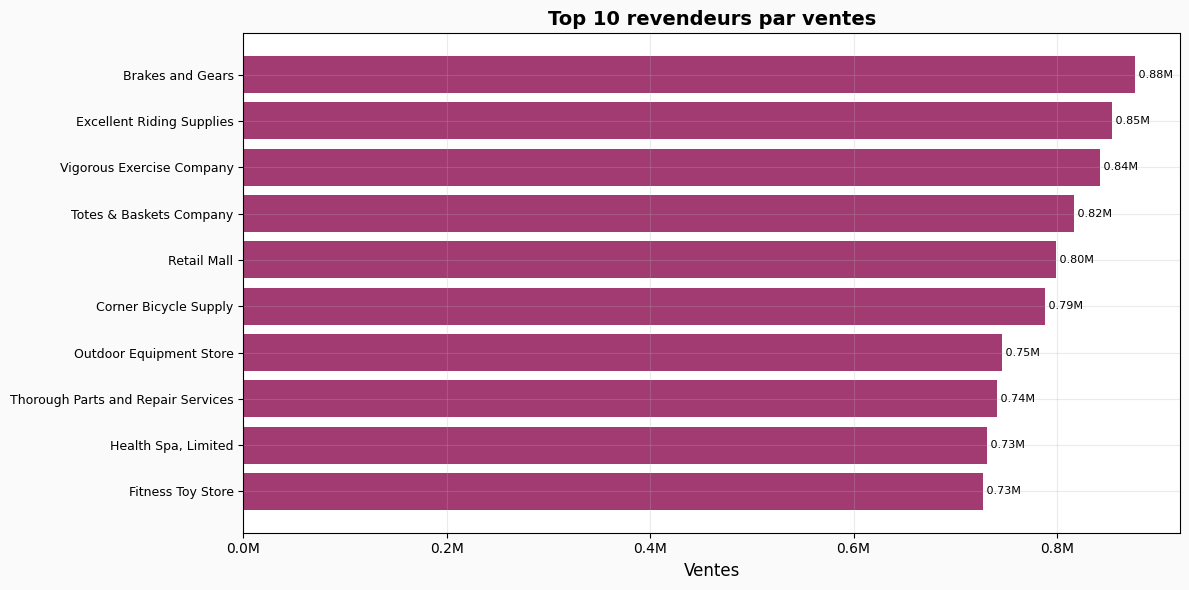

Sauvegardé : figures\resellers_top10_bars.png


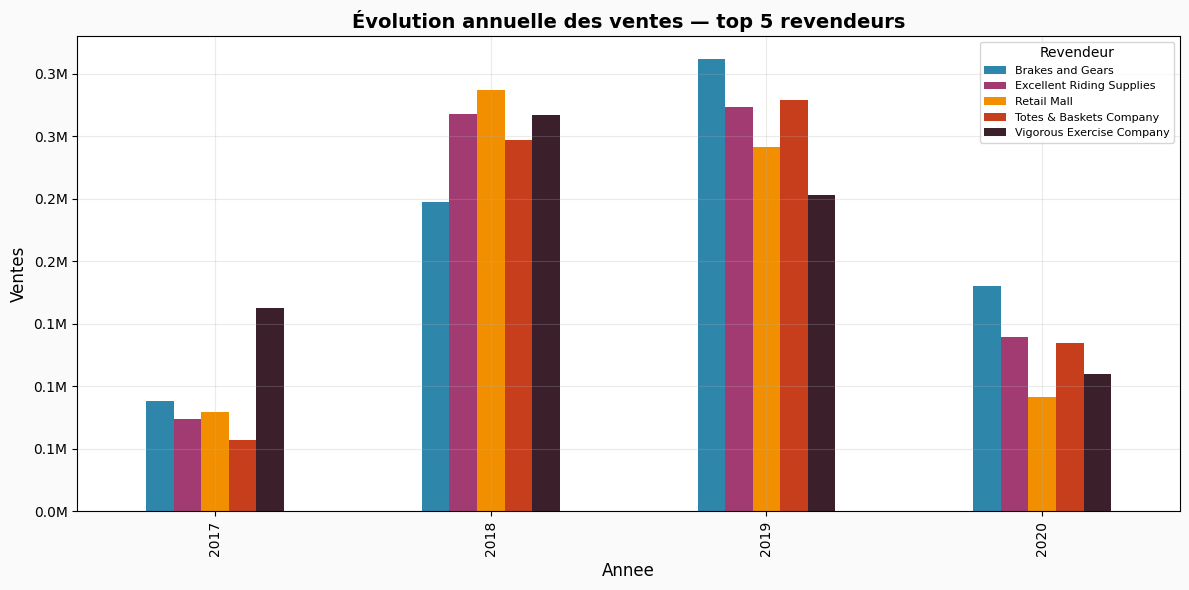

Sauvegardé : figures\resellers_by_year.png


In [18]:
reseller_sales = (
    sales_full.loc[sales_full['ResellerKey'] != -1]
    .groupby(['ResellerKey', 'Reseller'], observed=True)
    .agg(
        ventes=('Sales Amount', 'sum'),
        marge=('Margin', 'sum'),
        nb_lignes=('SalesOrderLineKey', 'count'),
    )
    .sort_values('ventes', ascending=False)
)

top_resellers = reseller_sales.head(10)
print('=== Top 10 revendeurs ===')
display(top_resellers.round(2))

fig, ax = plt.subplots(figsize=(12, 6))
labels = top_resellers.index.get_level_values('Reseller').astype(str)
bars = ax.barh(range(len(top_resellers)), top_resellers['ventes'].values, color='#A23B72')
ax.set_yticks(range(len(top_resellers)))
ax.set_yticklabels(labels, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Ventes')
ax.set_title('Top 10 revendeurs par ventes')
for bar, val in zip(bars, top_resellers['ventes'].values):
    ax.text(
        bar.get_width(),
        bar.get_y() + bar.get_height() / 2,
        f' {val/1e6:.2f}M',
        va='center',
        fontsize=8,
    )
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
fig.tight_layout()
out = FIGURES / 'resellers_top10_bars.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sauvegardé : {out}')

top_names = list(top_resellers.index.get_level_values('Reseller')[:5])
reseller_period = (
    sales_full.loc[sales_full['ResellerKey'] != -1]
    .assign(Annee=lambda d: d['OrderDate'].dt.year)
    .groupby(['Annee', 'Reseller'], observed=True)['Sales Amount']
    .sum()
    .reset_index()
)
rp_top = reseller_period[reseller_period['Reseller'].isin(top_names)]
pivot_rp = rp_top.pivot_table(
    index='Annee', columns='Reseller', values='Sales Amount', aggfunc='sum', fill_value=0
)

fig, ax = plt.subplots(figsize=(12, 6))
pivot_rp.plot(kind='bar', ax=ax)
ax.set_title('Évolution annuelle des ventes — top 5 revendeurs')
ax.set_ylabel('Ventes')
ax.legend(title='Revendeur', fontsize=8)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e6:.1f}M'))
fig.tight_layout()
out = FIGURES / 'resellers_by_year.png'
fig.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f'Sauvegardé : {out}')


## 10. Présentation — bureau de décision

### Conseils / questions pour améliorer les performances
- Concentrer stock et marketing sur les **territoires leaders**, tout en investiguant les territoires à **fort coefficient de variation** (paniers hétérogènes).
- Capitaliser sur les catégories / modèles dominants (souvent **Bikes**) et tester du cross-sell Accessories / Clothing pour hausser le panier moyen.
- Suivre la corrélation **ventes ↔ marge** : pousser les lignes à forte marge ; auditer les lignes à marge négative (coûts / remises).
- Top revendeurs : objectifs trimestriels ; reste du réseau : activation (formation, promos ciblées).

### Autres graphiques envisageables
- Prévision des ventes mensuelles (ARIMA / Prophet / régression).
- Funnel canal Reseller vs Internet.
- Cohortes clients (rétention) et LTV.
- Carte géographique des ventes.

### Données supplémentaires souhaitées
- Coûts marketing / acquisition par canal.
- Stocks et ruptures par SKU / entrepôt.
- Satisfaction client (NPS) et retours.
- Grilles de remise officielles (pour valider les remises implicites du nettoyage).
- Prix marché / données concurrentielles.
